Group size comparison


,Variation,num_clients
0,Test,26777
1,Control,23356


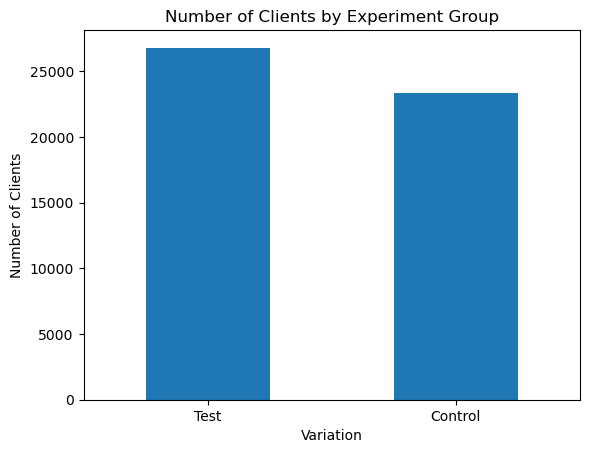

Distribution of user journeys


Variation,Control,Test
furthest_step,,
confirm,15892,21558
start,7560,5080
step_1,3483,3899
step_2,2036,2566
step_3,3044,3845


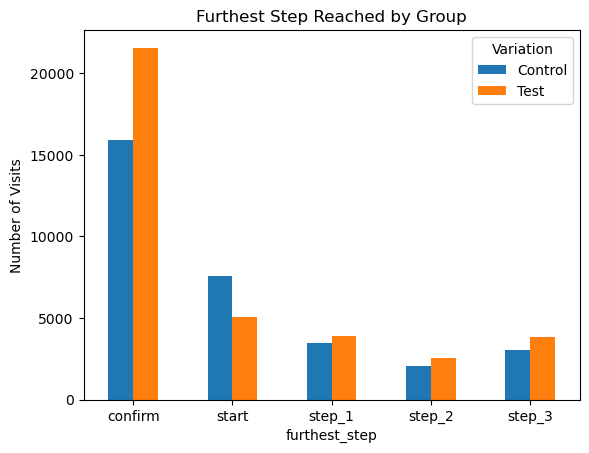

Completion rate comparison


,Variation,completion_rate_pct
0,Control,49.639232
1,Test,58.346866


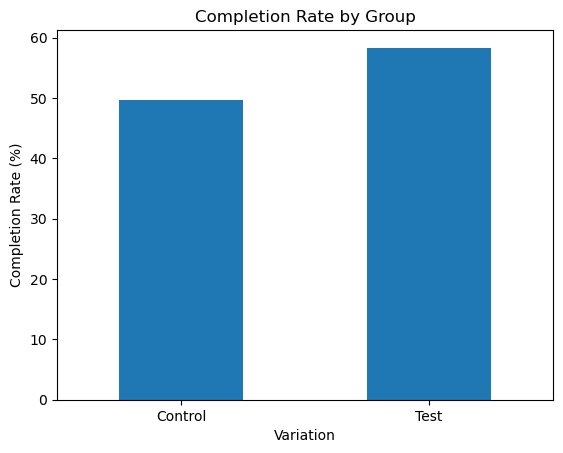

Average time spent on the journey


,Variation,time_diff
0,Control,280.181571
1,Test,315.084308


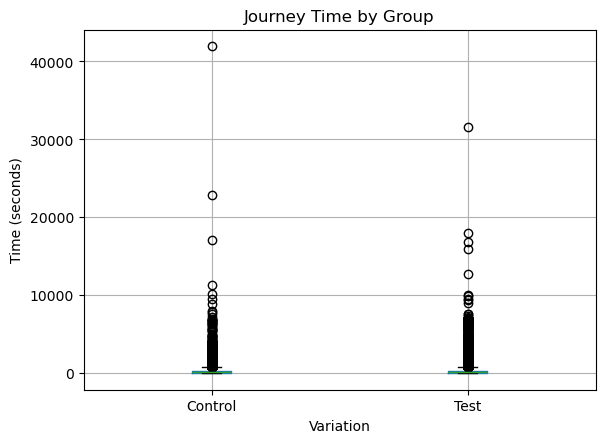

Error rate comparison


,Variation,error_rate_pct
0,Control,20.224895
1,Test,26.832305


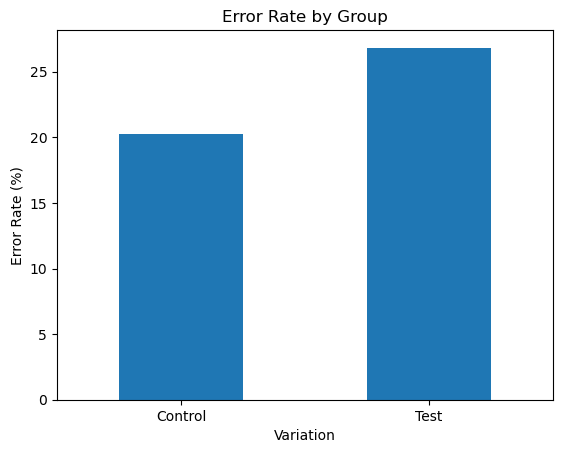

In [ ]:
# 7. Exploratory Data Analysis (EDA)

import pandas as pd
import matplotlib.pyplot as plt

df_web = pd.read_csv("https://raw.githubusercontent.com/ngocha2811/ab-testing-vanguard-digital-journey/refs/heads/main/data/clean/df_web.csv")  # Replace with your actual file path




In [3]:
# Make sure date_time is in datetime format
df_web["date_time"] = pd.to_datetime(df_web["date_time"])

# If not already created, encode the process steps
step_map = {
    "start": 0,
    "step_1": 1,
    "step_2": 2,
    "step_3": 3,
    "confirm": 4
}

if "process_step_encoded" not in df_web.columns:
    df_web["process_step_encoded"] = df_web["process_step"].map(step_map)

Group size comparison


,Variation,num_clients
0,Test,26777
1,Control,23356


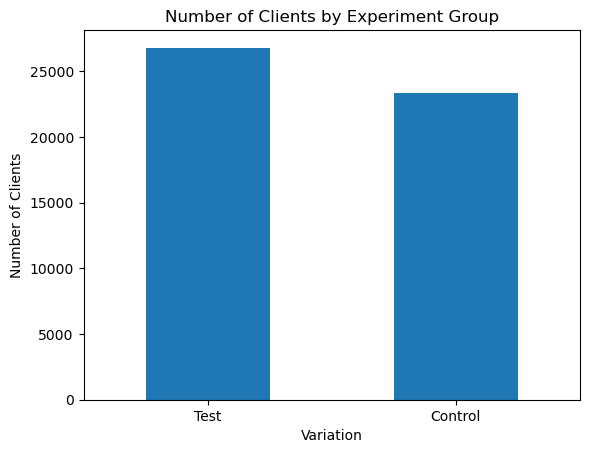

In [4]:

# --------------------------------------------------
# 1. Group size comparison
# --------------------------------------------------
group_size = df_web[["client_id", "Variation"]].drop_duplicates()["Variation"].value_counts().reset_index()
group_size.columns = ["Variation", "num_clients"]
print("Group size comparison")
display(group_size)

group_size.plot(kind="bar", x="Variation", y="num_clients", legend=False)
plt.title("Number of Clients by Experiment Group")
plt.ylabel("Number of Clients")
plt.xticks(rotation=0)
plt.show()

Distribution of user journeys


Variation,Control,Test
furthest_step,,
confirm,15892,21558
start,7560,5080
step_1,3483,3899
step_2,2036,2566
step_3,3044,3845


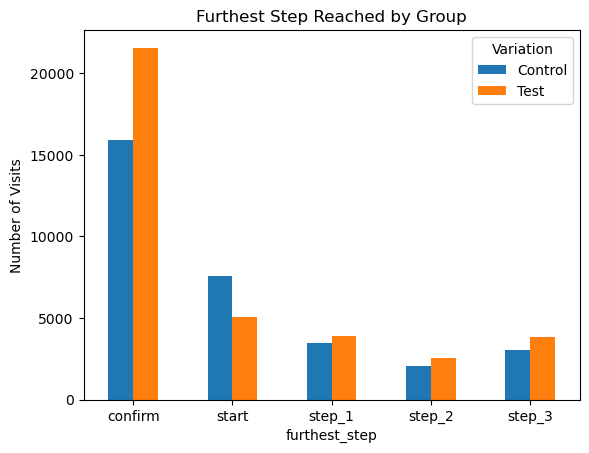

In [5]:
# --------------------------------------------------
# 2. Distribution of user journeys
#    Number of steps reached per visit
# --------------------------------------------------


journey_dist = (
    df_web.groupby(["Variation", "visit_id"])["process_step_encoded"]
    .max()
    .reset_index()
)

journey_dist["furthest_step"] = journey_dist["process_step_encoded"].map({
    0: "start",
    1: "step_1",
    2: "step_2",
    3: "step_3",
    4: "confirm"
})

journey_summary = pd.crosstab(journey_dist["furthest_step"], journey_dist["Variation"])
print("Distribution of user journeys")
display(journey_summary)

journey_summary.plot(kind="bar")
plt.title("Furthest Step Reached by Group")
plt.ylabel("Number of Visits")
plt.xticks(rotation=0)
plt.show()

Completion rate comparison


,Variation,completion_rate_pct
0,Control,49.639232
1,Test,58.346866


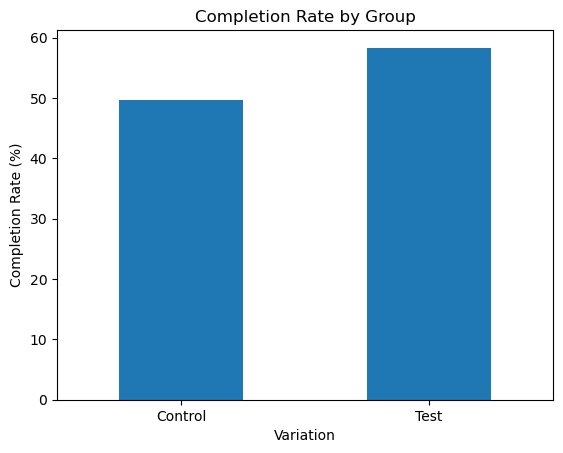

In [6]:
# --------------------------------------------------
# 3. Completion rate comparison
# --------------------------------------------------
completion_df = (
    df_web.groupby(["Variation", "visit_id"])["process_step_encoded"]
    .max()
    .reset_index()
)

completion_df["completed"] = completion_df["process_step_encoded"] == 4

completion_rate = (
    completion_df.groupby("Variation")["completed"]
    .mean()
    .reset_index()
)

completion_rate["completion_rate_pct"] = completion_rate["completed"] * 100

print("Completion rate comparison")
display(completion_rate[["Variation", "completion_rate_pct"]])

completion_rate.plot(kind="bar", x="Variation", y="completion_rate_pct", legend=False)
plt.title("Completion Rate by Group")
plt.ylabel("Completion Rate (%)")
plt.xticks(rotation=0)
plt.show()


Error rate comparison


,Variation,error_rate_pct
0,Control,20.224895
1,Test,26.832305


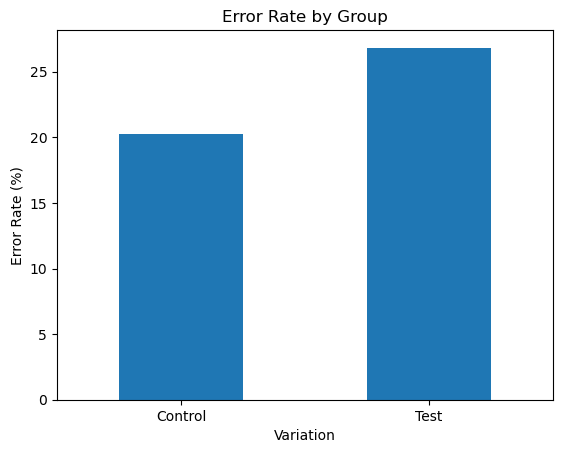

In [7]:
# --------------------------------------------------
# Optional: error rate comparison for EDA
# --------------------------------------------------
df_web = df_web.sort_values(["visit_id", "date_time"]).copy()
df_web["step_diff"] = df_web.groupby("visit_id")["process_step_encoded"].diff()

df_error = (
    df_web.groupby(["Variation", "visit_id"])["step_diff"]
    .min()
    .reset_index()
)

df_error["is_error"] = df_error["step_diff"] < 0

error_rate = (
    df_error.groupby("Variation")["is_error"]
    .mean()
    .reset_index()
)

error_rate["error_rate_pct"] = error_rate["is_error"] * 100

print("Error rate comparison")
display(error_rate[["Variation", "error_rate_pct"]])

error_rate.plot(kind="bar", x="Variation", y="error_rate_pct", legend=False)
plt.title("Error Rate by Group")
plt.ylabel("Error Rate (%)")
plt.xticks(rotation=0)
plt.show()